In [19]:
import os
import sys
import django

# Pointer vers le bon dossier
sys.path.insert(0, r'C:\Users\rwenc\Documents\SSMI\medical_system')
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'medical_system.settings')

os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

django.setup()

print("Django configuré avec succès !")

Django configuré avec succès !


In [20]:
import pandas as pd
from apps.dossiers.models import DossierMedical
from django.db.models import Count
from django.db.models.functions import TruncDate

# Extraire les consultations Paludisme jour par jour
serie_paludisme = DossierMedical.objects.filter(
    diagnostic='Paludisme'
).annotate(
    date=TruncDate('date_consultation')
).values('date').annotate(
    nombre=Count('id')
).order_by('date')

# Convertir en DataFrame
df = pd.DataFrame(list(serie_paludisme))
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Remplir les jours manquants avec interpolation linéaire
df = df.resample('D').sum()
df['nombre'] = df['nombre'].astype(float)
df['nombre'] = df['nombre'].replace(0, float('nan')).interpolate(method='linear')
df['nombre'] = df['nombre'].round().astype(int)

print(df)
print(f"\nNombre total de jours : {len(df)}")

            nombre
date              
2025-10-02       7
2025-10-03       8
2025-10-04       7
2025-10-05       7
2025-10-06       8
...            ...
2026-03-26       7
2026-03-27       7
2026-03-28       7
2026-03-29       8
2026-03-30       7

[180 rows x 1 columns]

Nombre total de jours : 180


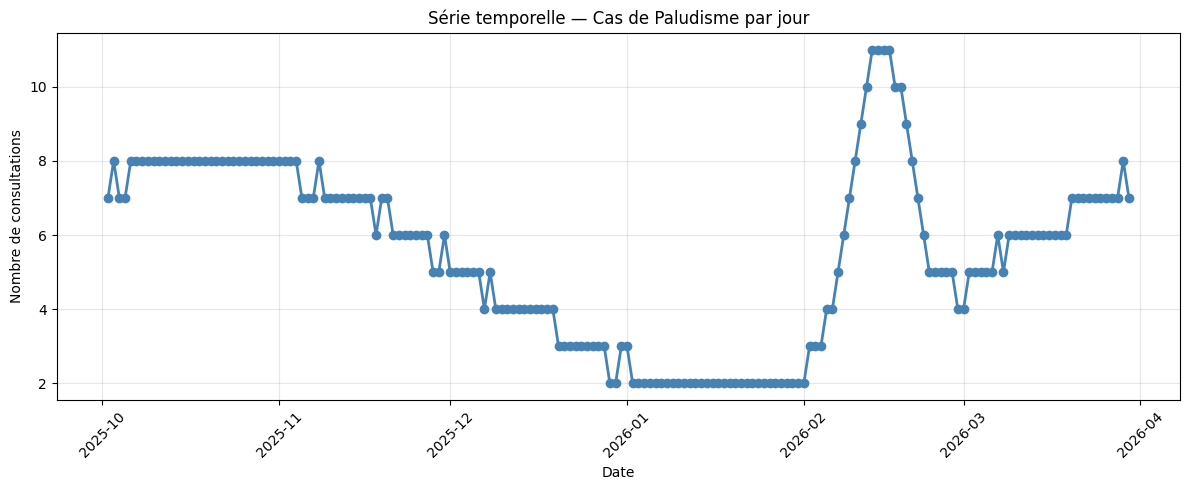

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['nombre'], marker='o', color='steelblue', linewidth=2)
plt.title('Série temporelle — Cas de Paludisme par jour')
plt.xlabel('Date')
plt.ylabel('Nombre de consultations')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Extraire les valeurs
valeurs = df['nombre'].values.reshape(-1, 1)

# 2. Normaliser entre 0 et 1 (le LSTM travaille mieux avec des petits chiffres)
scaler = MinMaxScaler()
valeurs_normalisees = scaler.fit_transform(valeurs)

# 3. Créer les fenêtres glissantes
def creer_sequences(data, taille_fenetre=7):
    X, y = [], []
    for i in range(len(data) - taille_fenetre):
        X.append(data[i:i+taille_fenetre])
        y.append(data[i+taille_fenetre])
    return np.array(X), np.array(y)

X, y = creer_sequences(valeurs_normalisees, taille_fenetre=7)

print(f"Forme de X : {X.shape}")
print(f"Forme de y : {y.shape}")
print(f"\nExemple — fenêtre 1 : {X[0].flatten()} → prédit : {y[0][0]:.2f}")

Forme de X : (173, 7, 1)
Forme de y : (173, 1)

Exemple — fenêtre 1 : [0.55555556 0.66666667 0.55555556 0.55555556 0.66666667 0.66666667
 0.66666667] → prédit : 0.67


In [23]:
import torch
import torch.nn as nn

# 1. Convertir en tenseurs PyTorch
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y)

# 2. Définir le modèle LSTM
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# 3. Initialiser le modèle
model = LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 4. Entraîner
epochs = 200
pertes = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()
    pertes.append(loss.item())
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Perte : {loss.item():.6f}")

print("\nEntraînement terminé !")

Epoch 50/200 — Perte : 0.006795
Epoch 100/200 — Perte : 0.002247
Epoch 150/200 — Perte : 0.001954
Epoch 200/200 — Perte : 0.001787

Entraînement terminé !


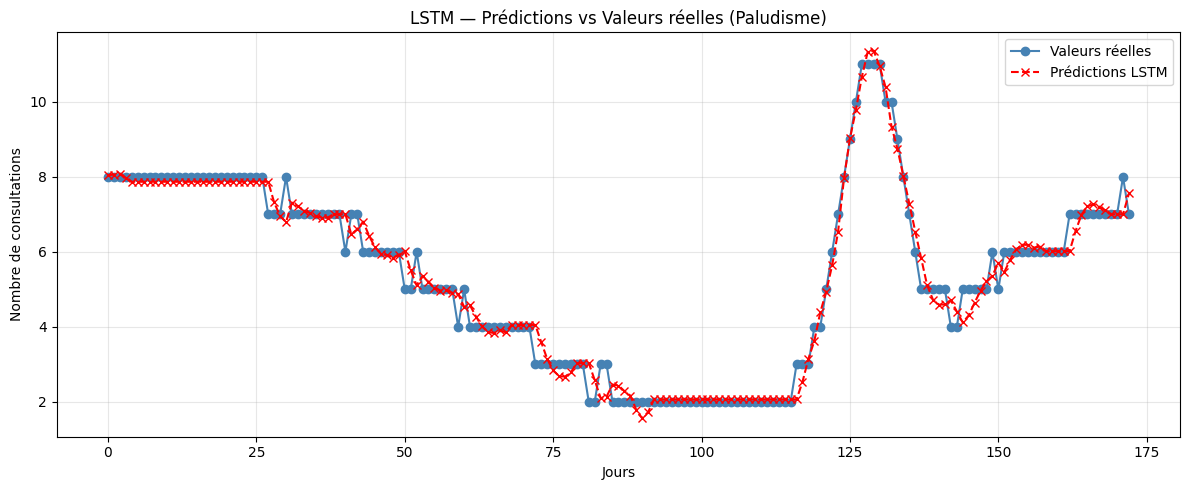

In [24]:
# 1. Faire les prédictions
model.eval()
with torch.no_grad():
    predictions = model(X_tensor).numpy()

# 2. Dénormaliser — revenir aux vrais chiffres
predictions_reelles = scaler.inverse_transform(predictions)
valeurs_reelles = scaler.inverse_transform(y)

# 3. Visualiser
plt.figure(figsize=(12, 5))
plt.plot(valeurs_reelles, label='Valeurs réelles', marker='o', color='steelblue')
plt.plot(predictions_reelles, label='Prédictions LSTM', marker='x', 
         color='red', linestyle='--')
plt.title('LSTM — Prédictions vs Valeurs réelles (Paludisme)')
plt.xlabel('Jours')
plt.ylabel('Nombre de consultations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# 1. Prendre les 7 derniers jours connus comme point de départ
derniers_jours = valeurs_normalisees[-7:].reshape(1, 7, 1)
derniers_jours_tensor = torch.FloatTensor(derniers_jours)

# 2. Prédire les 7 prochains jours un par un
predictions_futures = []
input_actuel = derniers_jours_tensor.clone()

model.eval()
with torch.no_grad():
    for i in range(7):
        # Prédire le prochain jour
        prediction = model(input_actuel)
        predictions_futures.append(prediction.item())
        
        # Décaler la fenêtre — ajouter la prédiction et enlever le premier jour
        nouveau_jour = prediction.unsqueeze(0)
        input_actuel = torch.cat([input_actuel[:, 1:, :], nouveau_jour], dim=1)

# 3. Dénormaliser
predictions_futures = np.array(predictions_futures).reshape(-1, 1)
predictions_futures_reelles = scaler.inverse_transform(predictions_futures)
predictions_futures_reelles = predictions_futures_reelles.round().astype(int)

# 4. Créer les dates futures
import pandas as pd
derniere_date = df.index[-1]
dates_futures = pd.date_range(
    start=derniere_date + pd.Timedelta(days=1), 
    periods=7
)

# 5. Afficher
print("Prédictions pour les 7 prochains jours :\n")
for date, valeur in zip(dates_futures, predictions_futures_reelles):
    print(f"{date.strftime('%Y-%m-%d')} → {valeur[0]} cas prévus")

Prédictions pour les 7 prochains jours :

2026-03-31 → 7 cas prévus
2026-04-01 → 7 cas prévus
2026-04-02 → 7 cas prévus
2026-04-03 → 7 cas prévus
2026-04-04 → 7 cas prévus
2026-04-05 → 7 cas prévus
2026-04-06 → 7 cas prévus


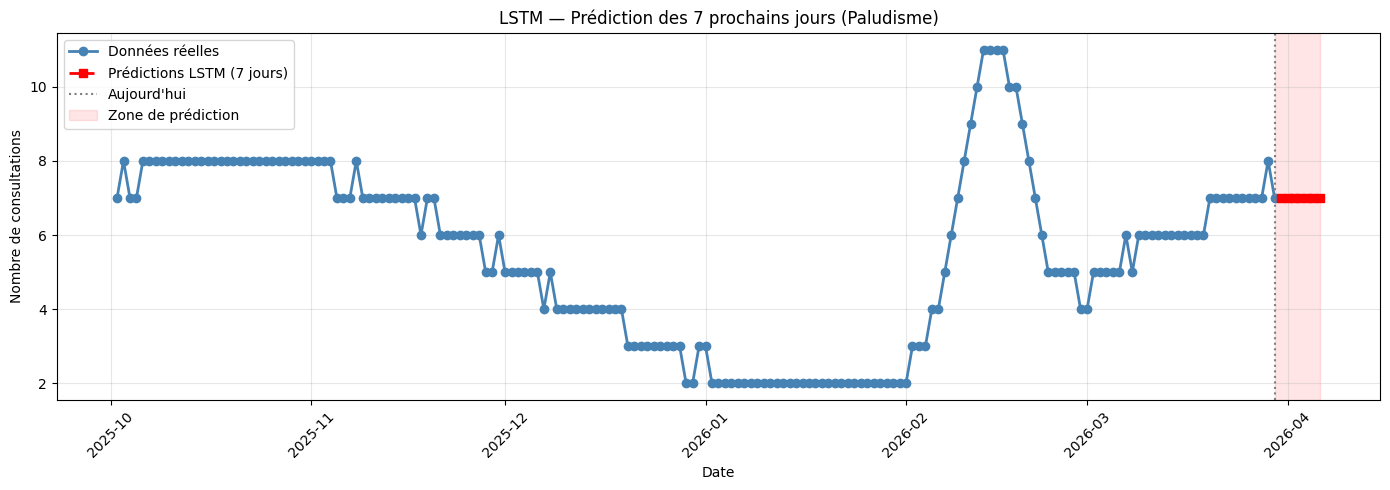

In [26]:
plt.figure(figsize=(14, 5))

# Données historiques
plt.plot(df.index, df['nombre'], 
         marker='o', color='steelblue', 
         linewidth=2, label='Données réelles')

# Prédictions futures
plt.plot(dates_futures, predictions_futures_reelles, 
         marker='s', color='red', 
         linewidth=2, linestyle='--',
         label='Prédictions LSTM (7 jours)')

# Ligne verticale séparant passé et futur
plt.axvline(x=derniere_date, color='gray', 
            linestyle=':', linewidth=1.5, 
            label='Aujourd\'hui')

# Zone de prédiction
plt.axvspan(derniere_date, dates_futures[-1], 
            alpha=0.1, color='red', 
            label='Zone de prédiction')

plt.title('LSTM — Prédiction des 7 prochains jours (Paludisme)')
plt.xlabel('Date')
plt.ylabel('Nombre de consultations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
import os
import torch
import pickle

# Créer le dossier de sauvegarde
os.makedirs('models', exist_ok=True)

# Sauvegarder le modèle LSTM
torch.save(model.state_dict(), 
           'models/lstm_paludisme.pth')

# Sauvegarder le scaler
with open('models/scaler_lstm.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Modèle LSTM sauvegardé !")
print("  models/lstm_paludisme.pth")
print("  models/scaler_lstm.pkl")

Modèle LSTM sauvegardé !
  models/lstm_paludisme.pth
  models/scaler_lstm.pkl


In [28]:
# ── Tester l'intégration dans epidemic_prediction.py ──────

import sys
sys.path.insert(0, r'C:\Users\rwenc\Documents\SSMI\medical_system')

from apps.stats_medicales.epidemic_prediction import EpidemicPredictor

# Tester la prédiction
resultats = EpidemicPredictor.analyser_tendances_maladies(
    jours_historique=180,
    jours_prediction=7
)

print(f"Statut : {resultats['statut']}")
print(f"Risque épidémique : {resultats['risque_epidemique']['niveau']}")
print(f"\nPrédictions 7 jours :")
for i, pred in enumerate(resultats['predictions'], 1):
    print(f"  Jour {i} : {pred} cas")

Statut : success
Risque épidémique : faible

Prédictions 7 jours :
  Jour 1 : 15.2 cas
  Jour 2 : 11.8 cas
  Jour 3 : 9.0 cas
  Jour 4 : 6.6 cas
  Jour 5 : 4.8 cas
  Jour 6 : 3.7 cas
  Jour 7 : 3.2 cas


c:\Users\rwenc\Documents\SSMI\medical_system\ssmi\Lib\site-packages\django\db\models\fields\__init__.py:1665: RuntimeWarning: DateTimeField DossierMedical.date_consultation received a naive datetime (2025-10-03 02:21:28.631919) while time zone support is active.
  warnings.warn(
